In [2]:
import pickle
from hdf5storage import loadmat
import numpy as np

cpEDA:

In [45]:
n_items = 120
n_selected = 12
n_obj = 4

In [46]:
kn = loadmat(f'/data/knapsack/runA/kn_2_3_allneg_{n_items}_{n_selected}_{n_obj}.mat')
n_con = kn['n_con'] 
capacity = kn['capacity']

In [49]:
kn['r']

array([[ 1. , -0.2, -0.2, -0.2,  0.3],
       [-0.2,  1. , -0.2, -0.2,  0.3],
       [-0.2, -0.2,  1. , -0.2,  0.3],
       [-0.2, -0.2, -0.2,  1. ,  0.3],
       [ 0.3,  0.3,  0.3,  0.3,  1. ]])

In [47]:
num_obju = np.zeros(20)
num_cpf = np.zeros(20)
hv_obju = np.zeros(20)
hv_cpf = np.zeros(20)
ratio_dominated_obju = np.zeros(20)
ratio_dominated_cpf = np.zeros(20)
for i in range(20):
    with open(f'results_heuristic/heuristic_2_3_{n_items}_{n_selected}_obj{n_obj}_run{i}.pkl', 'rb') as f:
        results = pickle.load(f)
    num_obju[i] = results['num_obju']
    num_cpf[i] = results['num_cpf']
    hv_obju[i] = results['hv_obju']
    hv_cpf[i] = results['hv_cpf']
    ratio_dominated_obju[i] = results['ratio_dominated_obju']
    ratio_dominated_cpf[i] = results['ratio_dominated_cpf']

In [48]:
print(np.mean(num_obju))
print(np.mean(num_cpf))
print(np.log10(np.mean(hv_obju)))
print(np.log10(np.mean(hv_cpf)))
print(np.mean(ratio_dominated_obju))
print(np.mean(ratio_dominated_cpf))

598.05
9321.7
8.11246988494253
8.233322834314965
0.8655866688016088
0.0017829024310013625


Human input:

In [35]:
n_items = 60
n_selected = 6
n_obj = 3
kn = loadmat(f'/data/knapsack/runB/kn_2_3_allneg_{n_items}_{n_selected}_{n_obj}.mat')
n_con = kn['n_con'] 
capacity = kn['capacity']

In [4]:
from pymoo.indicators.hv import HV

def calculate_hv(obj1, n_obj):
    A = obj1.astype(np.float64)
    A_min = -A
    ref = np.zeros(n_obj)
    hv = HV(ref_point=ref)
    A_hv = hv(A_min)
    return A_hv

In [4]:
def calculate_dominated(obj1, obj2, n_obj):
    pf_predicted = obj1
    pf_actual = obj2
    dominated = np.zeros(len(pf_predicted))
    for i in range(len(pf_predicted)):
        for j in range(len(pf_actual)):
            if np.all(pf_actual[j, :n_obj] >= pf_predicted[i, :n_obj]) and \
                np.any(pf_actual[j, :n_obj] > pf_predicted[i, :n_obj]):
                dominated[i] = 1
                break
    return np.sum(dominated), np.sum(dominated)/len(pf_predicted)

In [12]:
with open(f'results_softmax/softmax_2_3_{n_items}_{n_selected}_obj{n_obj}_run5.pkl', 'rb') as f:
        results = pickle.load(f)

In [56]:
results["mode 2 generations"]

34

In [7]:
from numba import jit, prange, njit
@jit(nopython=True)
def non_dominated(objectives):
    n_solutions = objectives.shape[0]
    non_dominated = np.ones(n_solutions)
    for i in prange(n_solutions):
        for j in prange(n_solutions):
            if i == j:
                continue

            if np.all(objectives[j, :] >= objectives[i, :]) and \
                np.any(objectives[j, :] > objectives[i, :]):
                non_dominated[i] = 0
                break

    return non_dominated

In [42]:
num_dominated = np.zeros(3)
ratio_dominated = np.zeros(3)
for i in range(2):
    with open(f'softmax_mode1_2_3_{n_items}_{n_selected}_obj{n_obj}_run{i}.pkl', 'rb') as f:
        results = pickle.load(f)
    # gen = results['mode 2 generations'] - 1
    # pareto_fronts = np.vstack(results['pareto_front_table'][-gen:])
    # non_dominated_idx = non_dominated(pareto_fronts).astype(bool)
    # solutions = np.unique(pareto_fronts[non_dominated_idx], axis=0)
    solutions = results['pareto_front_accu_table'][-1]
    
    with open(f'results_final/final_2_3_{n_items}_{n_selected}_obj{n_obj}_run{i}.pkl', 'rb') as f:
        results_full = pickle.load(f)
    converged_pf_full = results_full['converged_pf_table'][-1]

    num, ratio = calculate_dominated(solutions, converged_pf_full, n_obj)
    num_dominated[i] = num
    ratio_dominated[i] = ratio

In [43]:
ratio_dominated

array([0.44827586, 0.6       , 0.        ])

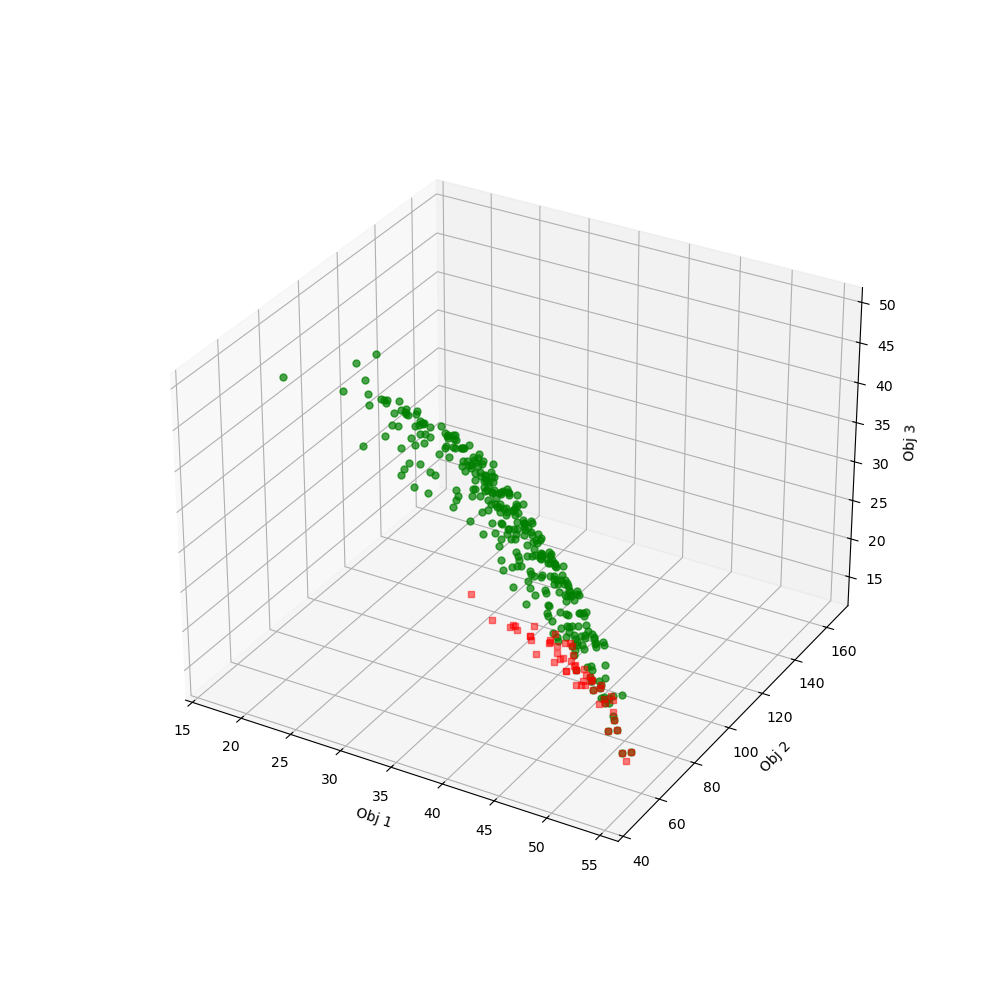

In [44]:
from matplotlib import pyplot as plt
%matplotlib widget
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection='3d')
ax.plot(converged_pf_full[:,0], converged_pf_full[:,1], converged_pf_full[:,2], 'go', alpha=0.7, markersize=5)
ax.plot(solutions[:,0], solutions[:,1], solutions[:,2], 'rs', alpha=0.5, markersize=5)
ax.set_xlabel('Obj 1')
ax.set_ylabel('Obj 2')
ax.set_zlabel('Obj 3')
plt.show()

In [29]:
num_solutions = np.zeros(20)
hv = np.zeros(20)
for i in range(20):
    with open(f'results_softmax/softmax_2_3_{n_items}_{n_selected}_obj{n_obj}_run{i}.pkl', 'rb') as f:
        results = pickle.load(f)
    solutions = results['pareto_front_accu_table']
    hv = calculate_hv(solutions, n_obj)
    num_solutions[i] = solutions.shape[0]
    hv[i] = hv
print(np.mean(num_solutions))
print(np.mean(hv))

NameError: name 'calculate_hv' is not defined